# *Music Genre Classification - Classifying the genre of a music using deep neural networks*

## Dataset description
The dataset used is [GTZAN](https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification) (the famous GTZAN dataset, the MNIST of sounds)

The GTZAN dataset contains 1000 audio files.
Contains a total of 10 genres, each genre contains 100 audio files

1.Blues

2.Classical

3.Country

4.Disco   

5.Hip-hop

6.Jazz   

7.Metal

8.Pop

9.Reggae

10.Rock

##### Genres original  
A compilation of ten genres, each with 100 audio recordings, each lasting 30 seconds (the famous GTZAN dataset, the MNIST of sounds)
##### Images original
Each audio file has a visual representation. Neural networks are one technique to classify data because they usually take in some form of picture representation.
##### CSV files
The audio files' features are contained within. Each song lasts for 30 seconds long has a mean and variance computed across several features taken from an audio file in one file. The songs are separated into 3 second audio files in the other file, which has the same format.


## Import libraries

In [47]:
# Importing all the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import os
import pickle
import librosa
import librosa.display
import IPython.display as ipd
from IPython.display import Audio
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential

In [65]:
# Reading the csv file
df = pd.read_csv("features_3_sec.csv")
df.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


In [66]:
# Shape of the data
df.shape

(9990, 60)

In [50]:
# Data type of the data
df.dtypes

,0
filename,object
length,int64
chroma_stft_mean,float64
chroma_stft_var,float64
rms_mean,float64
rms_var,float64
spectral_centroid_mean,float64
spectral_centroid_var,float64
spectral_bandwidth_mean,float64
spectral_bandwidth_var,float64


## Proposed Methodology
   ![Untitled Diagram.drawio (2).png](attachment:40f55db0-d807-4358-b63e-4f3c23c3898f.png)

In [51]:
# Loading a sample audio from the dataset
audio ="reggae.00010.wav"
data,sr=librosa.load(audio)
print(type(data),type(sr))
print(sr)

<class 'numpy.ndarray'> <class 'int'>
22050


In order to work with audio data we use [Librosa](https://librosa.org/doc/latest/index.html), a python
package used for audio and music analysis. It is a powerful package widely used for
audio visualization and for building MIR systems. We will be using the package for
loading and visualizing the audio data.

In [52]:
# Initializing sample rate to 45600 we obtain the signal value array
librosa.load(audio,sr=45600)

(array([-0.00555292, -0.00768963, -0.00668519, ...,  0.08035277,
         0.06637131,  0.03239053], dtype=float32),
 45600)

In [54]:
# Taking Short-time Fourier transform of the signal
y = librosa.stft(data)
S_db = librosa.amplitude_to_db(np.abs(y), ref=np.max)
S_db.shape

(1025, 1293)

In [9]:
# Playing audio file
import IPython
IPython.display.Audio(data,rate=sr)

It is important to note that while working with any kind of audio data to solve any kind of problem statement, using only .wav format audio files is appropriate to analyze the data. If you are given audio files with .mp3 format you have to batch convert the data to waveforms using online software as .wav is the standard way of representing the audio files and it is the only way to work with audio data. Below is the wave form representation on the audio

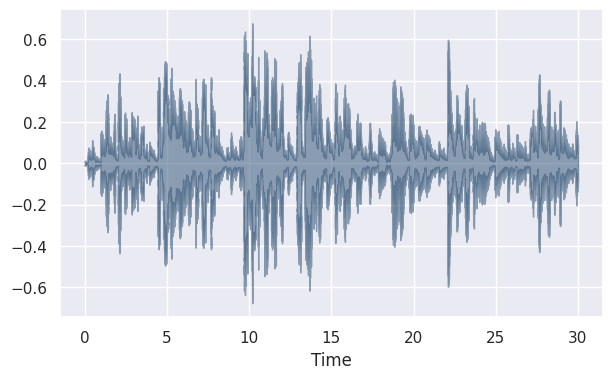

In [55]:
# Wave form of the audio
plt.figure(figsize=(7,4))
librosa.display.waveshow(data,color="#2B4F72", alpha = 0.5)
plt.show()

A spectrogram is a visual representation of the signal loudness of a signal over time at different frequencies included in a certain waveform. We can examine increase or decrease of energy over period of time. Spectrograms are also known as sonographs, voiceprints, and voicegrams.  We can also know how energy levels change over time period.

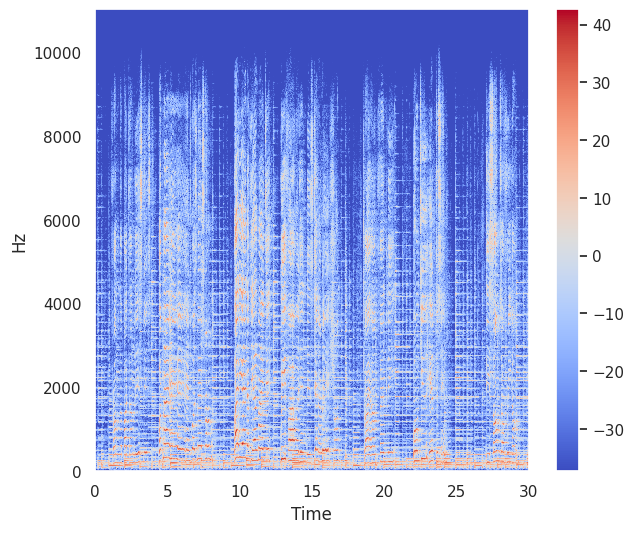

In [56]:
# Spectrogram of the audio
stft=librosa.stft(data)
stft_db=librosa.amplitude_to_db(abs(stft))
plt.figure(figsize=(7,6))
librosa.display.specshow(stft_db,sr=sr,x_axis='time',y_axis='hz')
plt.colorbar()

## Data Pre Processing

### Extracting Audio features
The process of extraction of features from the data to utilize them for analysis is
known as feature extraction. Each audio signal consists of various audio features
however we must extract features that are relevant to the problem that we are solving.
Here are some features listed which are used in our project.

In [57]:
# Finding misssing values
# Find all columns with any NA values
print("Columns containing missing values",list(df.columns[df.isnull().any()]))

Columns containing missing values []


In [58]:
# Label Encoding - encod the categorical classes with numerical integer values for training

# Blues - 0
# Classical - 1
# Country - 2
# Disco - 3
# Hip-hop - 4
# Jazz - 5
# Metal - 6
# Pop - 7
# Reggae - 8
# Rock - 9

class_encod=df.iloc[:,-1]
converter=LabelEncoder()
y=converter.fit_transform(class_encod)
print(y)


[0 0 0 ... 9 9 9]


In [67]:
#features
print(df.iloc[:,:-1])

               filename  length  chroma_stft_mean  chroma_stft_var  rms_mean  \
0     blues.00000.0.wav   66149          0.335406         0.091048  0.130405   
1     blues.00000.1.wav   66149          0.343065         0.086147  0.112699   
2     blues.00000.2.wav   66149          0.346815         0.092243  0.132003   
3     blues.00000.3.wav   66149          0.363639         0.086856  0.132565   
4     blues.00000.4.wav   66149          0.335579         0.088129  0.143289   
...                 ...     ...               ...              ...       ...   
9985   rock.00099.5.wav   66149          0.349126         0.080515  0.050019   
9986   rock.00099.6.wav   66149          0.372564         0.082626  0.057897   
9987   rock.00099.7.wav   66149          0.347481         0.089019  0.052403   
9988   rock.00099.8.wav   66149          0.387527         0.084815  0.066430   
9989   rock.00099.9.wav   66149          0.369293         0.086759  0.050524   

       rms_var  spectral_centroid_mean 

In [68]:
# Drop the column filename as it is no longer required for training
df=df.drop(labels="filename",axis=1)

In [62]:
#scaling
from sklearn.preprocessing import StandardScaler
fit=StandardScaler()
X=fit.fit_transform(np.array(df.iloc[:,:-1],dtype=float))

In [63]:
# splitting 70% data into training set and the remaining 30% to test set
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3)

In [32]:
# test data size
len(y_test)

2997

In [33]:
# size of training data
len(y_train)

6993

## K-Nearest Neighbors (KNN)
KNN is a fundamental Machine learning algorithm that is most commonly used
among all kinds of problems. It classifies the data points based on the point that is
near them by finding the euclidians distance given by d = ((x2-x1)^2 - (y2-y1)^2)^1/2 as a metric.

(6993, 58)
(2997, 58)
(6993,)
(2997,)
Training set score: 0.952
Test set score: 0.892
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       299
           1       0.89      0.93      0.91       302
           2       0.80      0.85      0.82       308
           3       0.84      0.91      0.87       307
           4       0.92      0.90      0.91       313
           5       0.89      0.86      0.87       295
           6       0.98      0.94      0.96       290
           7       0.93      0.82      0.87       292
           8       0.90      0.95      0.92       320
           9       0.90      0.82      0.86       271

    accuracy                           0.89      2997
   macro avg       0.89      0.89      0.89      2997
weighted avg       0.89      0.89      0.89      2997



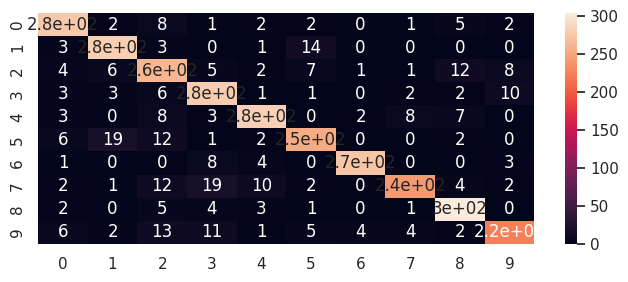

In [71]:
# Applying K nearest Neighbour algorithm to predict the results
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

clf1=KNeighborsClassifier(n_neighbors=3)
clf1.fit(X_train,y_train)
y_pred=clf1.predict(X_test)

print("Training set score: {:.3f}".format(clf1.score(X_train, y_train)))
print("Test set score: {:.3f}".format(clf1.score(X_test, y_test)))
cf_matrix = confusion_matrix(y_test, y_pred)
sns.set(rc = {'figure.figsize':(8,3)})
sns.heatmap(cf_matrix, annot=True)
print(classification_report(y_test,y_pred))


## Support Vector Machine (SVM)
SVM is one of the best machine learning models. Since the data is not linearly
separable, we have used the SVM kernel function as sigmoid. The sigmoid function is
given by
K(yn,yi) = tanh(-gamma*(yn,yi)+r)

Training set score: 0.919
Test set score: 0.844
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       264
           1       0.86      0.98      0.91       285
           2       0.79      0.76      0.78       312
           3       0.77      0.84      0.80       288
           4       0.93      0.82      0.87       320
           5       0.87      0.87      0.87       312
           6       0.90      0.91      0.91       317
           7       0.90      0.86      0.88       285
           8       0.80      0.84      0.82       287
           9       0.78      0.72      0.75       327

    accuracy                           0.84      2997
   macro avg       0.85      0.85      0.84      2997
weighted avg       0.85      0.84      0.84      2997



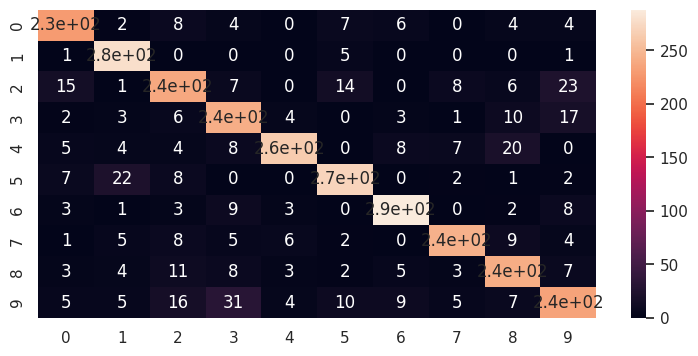

In [35]:
# Applying Support Vector Machines to predict the results
from sklearn.svm import SVC
svclassifier = SVC(kernel='rbf', degree=8)
svclassifier.fit(X_train, y_train)
print("Training set score: {:.3f}".format(svclassifier.score(X_train, y_train)))
print("Test set score: {:.3f}".format(svclassifier.score(X_test, y_test)))
y_pred = svclassifier.predict(X_test)
cf_matrix3 = confusion_matrix(y_test, y_pred)
sns.set(rc = {'figure.figsize':(9,4)})
sns.heatmap(cf_matrix3, annot=True)
print(classification_report(y_test, y_pred))

## References

1.[https://www.tensorflow.org/datasets/catalog/gtzan](https://www.tensorflow.org/datasets/catalog/gtzan)

2.[https://www.kaggle.com/code/dapy15/music-genre-classification](https://www.kaggle.com/code/dapy15/music-genre-classification)

3.[https://www.clairvoyant.ai/blog/music-genre-classification-using-cnn](https://www.clairvoyant.ai/blog/music-genre-classification-using-cnn)

4.[https://github.com/alikaratana/Music-Genre-Classification](https://github.com/alikaratana/Music-Genre-Classification)